In [1]:
import scanpy as sc
import scvi
import numpy as np
import pandas as pd

# load data
adata = sc.read_h5ad("../data/obesity_challenge_2.h5ad")

# load genes to predict
genes_to_predict = pd.read_csv(
    "../data/predict_genes_2.txt",
    header=None
)[0].tolist()

print(adata)
print("genes_to_predict:", len(genes_to_predict))

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 90815 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'
genes_to_predict: 36601


In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
from pathlib import Path


def compute_and_save_hvg(
    adata,
    save_dir="../data/preprocessed/HVG/",
    n_top_genes=5000
):
    
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=n_top_genes,
        flavor="seurat_v3"
    )

    hvg_genes = adata.var_names[
        adata.var["highly_variable"]
    ].tolist()

    save_path = Path(save_dir) / f"hvg{n_top_genes}_genes.txt"

    pd.Series(hvg_genes).to_csv(
        save_path,
        index=False,
        header=False
    )

    print(f"HVG saved to {save_path}")
    print(f"HVG{n_top_genes}:", len(hvg_genes))
    return hvg_genes

hvg_genes = compute_and_save_hvg(adata, n_top_genes=8000)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


HVG saved to ../data/preprocessed/HVG/hvg8000_genes.txt
HVG8000: 8000


In [4]:
import pandas as pd

# 讀取 csv
sig_df = pd.read_csv("../data/signature_genes.csv")

# 只取 sig_gene 欄位
sig_genes = sig_df["sig_gene"].unique().tolist()

print("signature gene 數量:", len(sig_genes))

signature gene 數量: 820


In [5]:
hvg_set = set(hvg_genes)
sig_set = set(sig_genes)

overlap = sorted(hvg_set.intersection(sig_set))

print("overlap gene 數量:", len(overlap))
print("overlap genes:")
print(overlap[:20])

overlap gene 數量: 285
overlap genes:
['ABCA1', 'ABCD2', 'ABHD5', 'ACAA2', 'ACACA', 'ACACB', 'ACER3', 'ACLY', 'ACSF2', 'ACSL1', 'ACSL3', 'ACSL4', 'ACSL5', 'ACSM1', 'ACTL6B', 'ADAM17', 'ADAMTS5', 'ADAMTSL1', 'ADCY1', 'ADIPOQ']


In [14]:
hvg_genes = compute_and_save_hvg(adata, n_top_genes=3000)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


HVG saved to ../data/preprocessed/hvg3000_genes.txt
HVG3000: 3000


In [13]:
hvg_genes = compute_and_save_hvg(adata, n_top_genes=10000)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


HVG saved to ../data/preprocessed/hvg10000_genes.txt
HVG10000: 10000


In [3]:
# convert to dense if sparse
X = adata.X
if not isinstance(X, np.ndarray):
    X = X.toarray()

gene_means = X.mean(axis=0)
gene_stds = X.std(axis=0)

stats_df = pd.DataFrame({
    "gene": adata.var_names,
    "mean": gene_means,
    "std": gene_stds
})

stats_df.head()

,gene,mean,std
0,MIR1302-2HG,0.000582,0.043405
1,FAM138A,0.000000,0.000000
2,OR4F5,0.000000,0.000000
3,AL627309.1,0.005706,0.130069
4,AL627309.3,0.000991,0.052100


In [4]:
zero_genes = stats_df[
    (stats_df["mean"] == 0) &
    (stats_df["std"] == 0)
]

print("genes with mean=0 & std=0:", len(zero_genes))
zero_genes.head()

genes with mean=0 & std=0: 4378


,gene,mean,std
1,FAM138A,0.0,0.0
2,OR4F5,0.0,0.0
5,AL627309.2,0.0,0.0
7,AL627309.4,0.0,0.0
9,AL732372.1,0.0,0.0


In [5]:
stats_df["is_hvg"] = stats_df["gene"].isin(hvg_genes)

hvg_stats = stats_df[stats_df["is_hvg"]]
non_hvg_stats = stats_df[~stats_df["is_hvg"]]

print("HVG mean std:")
print(hvg_stats[["mean","std"]].describe())

print("\nNon-HVG mean std:")
print(non_hvg_stats[["mean","std"]].describe())

HVG mean std:
              mean          std
count  5000.000000  5000.000000
mean      1.224011     0.858264
std       1.546363     0.831717
min       0.000059     0.013306
25%       0.000341     0.033279
50%       0.084971     0.514711
75%       2.547923     1.766795
max      11.069978     3.547024

Non-HVG mean std:
               mean           std
count  31601.000000  31601.000000
mean       0.284536      0.424648
std        0.757967      0.551331
min        0.000000      0.000000
25%        0.000224      0.025023
50%        0.005481      0.125925
75%        0.186939      0.705122
max       10.137283      1.811329


In [6]:
predict_stats = stats_df[
    stats_df["gene"].isin(genes_to_predict)
]

predict_stats["is_hvg"] = predict_stats["gene"].isin(hvg_genes)

predict_hvg = predict_stats[predict_stats["is_hvg"]]
predict_non_hvg = predict_stats[~predict_stats["is_hvg"]]

print("predict genes in HVG:", len(predict_hvg))
print("predict genes NOT in HVG:", len(predict_non_hvg))

predict_non_hvg.describe()

predict genes in HVG: 5000
predict genes NOT in HVG: 31601


,mean,std
count,31601.000000,31601.000000
mean,0.284536,0.424648
std,0.757967,0.551331
min,0.000000,0.000000
25%,0.000224,0.025023
50%,0.005481,0.125925
75%,0.186939,0.705122
max,10.137283,1.811329


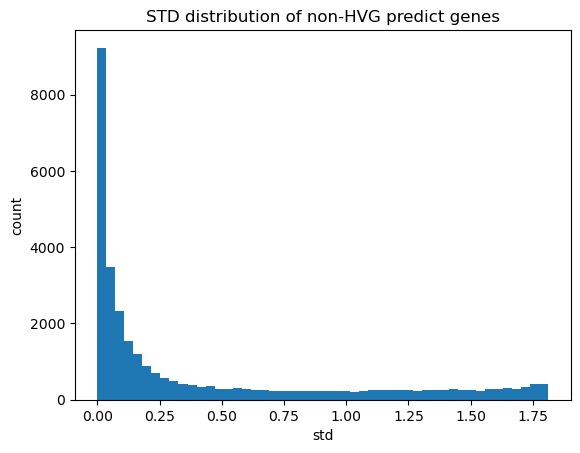

In [7]:
import matplotlib.pyplot as plt

plt.hist(
    predict_non_hvg["std"],
    bins=50
)

plt.title("STD distribution of non-HVG predict genes")
plt.xlabel("std")
plt.ylabel("count")
plt.show()